# Evaluación del desbalance entre la cobertura de servicio asignada y la demanda de pasajeros en las estaciones troncales de TransMilenio (2024–2025)

**Autor:** Iván Ramiro Pinzón Pinto 

**Programa:** Profesional en Ciencia de Datos — Universidad Externado de Colombia 

**Tutora:** Yessica Velásquez

In [1]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
from glob import glob
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Configuración y carga de datos

**Instrucción:** Ajustar `DATA_DIR` a la carpeta donde están los 24 archivos de validaciones, y las rutas de los archivos de soporte a su ubicación local.

In [ ]:
# =============================================
# CONFIGURACIÓN DE RUTAS — AJUSTAR SEGÚN TU PC
# =============================================
# Archivos de soporte
MATRIZ_PATH = os.path.join('matriz_paradas_troncales_dic2025.csv')
SERVICIOS_PATH = os.path.join('Servicios__Rutas_Troncales_y_Zonales_.csv')
ESTACIONES_OFICIAL_PATH = os.path.join('Estaciones_Troncales_de_TRANSMILENIO.csv')
CODE_MAPPING_PATH = os.path.join('code_to_matriz.json')

# Verificar
for path in [MATRIZ_PATH, SERVICIOS_PATH, CODE_MAPPING_PATH]:
    status = "OK" if os.path.exists(path) else "FALTA"
    print(f"  {status}: {os.path.basename(path)}")

# Listar archivos de validaciones
val_files = sorted(glob(os.path.join('*Validaciones*Troncales*.xlsx')))
print(f"\nArchivos de validaciones encontrados: {len(val_files)}")
for f in val_files:
    print(f"  {os.path.basename(f)}")

  OK: matriz_paradas_troncales_dic2025.csv
  OK: Servicios__Rutas_Troncales_y_Zonales_.csv
  OK: code_to_matriz.json

Archivos de validaciones encontrados: 24
  01 TM Resumen de Validaciones Troncales al 31 Ene 2024 Intervalo 15 Mint.xlsx
  01 TM Resumen de Validaciones Troncales al 31 de Enero 2025 Intervalo 15 Mint.xlsx
  02 TM Resumen de Validaciones Troncales al 28 de Febrero 2025 Intervalo 15 Mint.xlsx
  02 TM Resumen de Validaciones Troncales al 29 Feb 2024 Intervalo 15 Mint.xlsx
  03 TM Resumen de Validaciones Troncales al 31 Mar 2024 Intervalo 15 Mint.xlsx
  03 TM Resumen de Validaciones Troncales al 31 de Marzo 2025 Intervalo 15 Mint.xlsx
  04 TM Resumen de Validaciones Troncales al 30 Abr 2024 Intervalo 15 Mint.xlsx
  04 TM Resumen de Validaciones Troncales al 30 de Abril 2025 Intervalo 15 Mint.xlsx
  05 TM Resumen de Validaciones Troncales al 31 May 2024 Intervalo 15 Mint.xlsx
  05 TM Resumen de Validaciones Troncales al 31 de Mayo 2025 Intervalo 15 Mint.xlsx
  06 TM Resumen

In [3]:
# =============================================
# CARGA DE DATOS DE SOPORTE
# =============================================

# 1. Matriz ruta-estación
matriz = pd.read_csv(MATRIZ_PATH)
print(f"Matriz ruta-estación: {len(matriz)} filas, "
      f"{matriz['ruta'].nunique()} rutas, {matriz['estacion'].nunique()} estaciones")

# 2. Servicios troncales (para tipo de bus)
servicios = pd.read_csv(SERVICIOS_PATH)
troncal_serv = servicios[servicios['tip_operac'] == 1][['cod_ruta', 'tip_bus']].drop_duplicates()
print(f"Servicios troncales: {len(troncal_serv)} rutas con tipo de bus")

# 3. Mapeo de códigos de estación
with open(CODE_MAPPING_PATH, 'r', encoding='utf-8') as f:
    code_to_matriz = json.load(f)
print(f"Mapeo de códigos: {len(code_to_matriz)} códigos -> "
      f"{len(set(code_to_matriz.values()))} estaciones únicas")

Matriz ruta-estación: 1547 filas, 101 rutas, 232 estaciones
Servicios troncales: 111 rutas con tipo de bus
Mapeo de códigos: 154 códigos -> 140 estaciones únicas


## 2. Estandarización de estaciones (mapeo por código)

Las validaciones TuLlave usan el formato `(XXXXX) Nombre Estación`. El código numérico es el identificador estable; el nombre textual varía entre meses.

In [4]:
def extraer_codigo(estacion_raw):
    """Extrae el código numérico del nombre crudo de estación."""
    m = re.match(r'\((\d+)\)', str(estacion_raw).strip())
    return m.group(1) if m else None

def mapear_estacion(estacion_raw):
    """Mapea nombre crudo de validaciones al nombre estandarizado de la matriz."""
    code = extraer_codigo(estacion_raw)
    if code and code in code_to_matriz:
        return code_to_matriz[code]
    return None

# Verificación
tests = [
    '(02000) Cabecera Autopista Norte',
    '(05000) Portal Américas',
    '(09110) Avenida Jimenez',
    '(06101) El Tiempo',
    '(06101) El Tiempo - Camara de Comercio de Bogota',
]
print("Verificación del mapeo por código:")
for t in tests:
    print(f"  {t:55s} -> {mapear_estacion(t)}")

Verificación del mapeo por código:
  (02000) Cabecera Autopista Norte                        -> Terminal
  (05000) Portal Américas                                 -> Portal Américas
  (09110) Avenida Jimenez                                 -> AV. Jiménez
  (06101) El Tiempo                                       -> El Tiempo - CCB
  (06101) El Tiempo - Camara de Comercio de Bogota        -> El Tiempo - CCB


## 3. Consolidación de validaciones (24 meses)

Se cargan los 24 archivos mensuales, se transforman de formato ancho a largo, se aplica el mapeo por código y se agregan validaciones por estación-fecha-intervalo.

In [5]:
def leer_validaciones(filepath):
    """Lee un archivo mensual de validaciones y lo transforma a formato largo."""
    df = pd.read_excel(filepath, header=None, skiprows=6)
    df.columns = df.iloc[0]
    df = df.iloc[1:].copy()
    fname = os.path.basename(filepath)
    
    meta_cols = ['Fase', 'Línea', 'Estación', 'Acceso de Estación', 'Intervalo']
    day_cols = [c for c in df.columns if c not in meta_cols and c is not None]
    
    df = df[df['Estación'].notna()].copy()
    df['estacion'] = df['Estación'].apply(mapear_estacion)
    
    n_before = len(df)
    df = df[df['estacion'].notna()].copy()
    n_after = len(df)
    
    id_vars = ['estacion', 'Intervalo']
    value_vars = [c for c in day_cols if str(c).strip() not in ['', 'None', 'Total general']]
    
    melted = df.melt(id_vars=id_vars, value_vars=value_vars,
                     var_name='fecha', value_name='validaciones')
    
    melted['validaciones'] = pd.to_numeric(melted['validaciones'], errors='coerce').fillna(0).astype(int)
    melted['fecha'] = pd.to_datetime(melted['fecha'], errors='coerce')
    melted = melted.dropna(subset=['fecha'])
    melted = melted.rename(columns={'Intervalo': 'intervalo'})
    
    result = melted.groupby(['estacion', 'fecha', 'intervalo'])['validaciones'].sum().reset_index()
    print(f"  {fname}: {n_after}/{n_before} filas mapeadas -> {len(result)} registros")
    return result

# Cargar todos los archivos
print("Cargando validaciones...\n")
all_dfs = []
for f in val_files:
    try:
        df = leer_validaciones(f)
        all_dfs.append(df)
    except Exception as e:
        print(f"  ERROR en {os.path.basename(f)}: {e}")

validaciones = pd.concat(all_dfs, ignore_index=True)
validaciones = validaciones.groupby(['estacion', 'fecha', 'intervalo'])['validaciones'].sum().reset_index()

print(f"\n{'='*50}")
print(f"CONSOLIDADO FINAL")
print(f"  Filas totales:      {len(validaciones):,}")
print(f"  Estaciones únicas:  {validaciones['estacion'].nunique()}")
print(f"  Rango de fechas:    {validaciones['fecha'].min()} a {validaciones['fecha'].max()}")
print(f"  Meses cubiertos:    {validaciones['fecha'].dt.to_period('M').nunique()}")

Cargando validaciones...

  01 TM Resumen de Validaciones Troncales al 31 Ene 2024 Intervalo 15 Mint.xlsx: 38266/69821 filas mapeadas -> 341217 registros
  01 TM Resumen de Validaciones Troncales al 31 de Enero 2025 Intervalo 15 Mint.xlsx: 38743/52567 filas mapeadas -> 331855 registros
  02 TM Resumen de Validaciones Troncales al 28 de Febrero 2025 Intervalo 15 Mint.xlsx: 37928/56448 filas mapeadas -> 333498 registros
  02 TM Resumen de Validaciones Troncales al 29 Feb 2024 Intervalo 15 Mint.xlsx: 38452/52953 filas mapeadas -> 342488 registros
  03 TM Resumen de Validaciones Troncales al 31 Mar 2024 Intervalo 15 Mint.xlsx: 37923/53389 filas mapeadas -> 342519 registros
  03 TM Resumen de Validaciones Troncales al 31 de Marzo 2025 Intervalo 15 Mint.xlsx: 37884/52608 filas mapeadas -> 333529 registros
  04 TM Resumen de Validaciones Troncales al 30 Abr 2024 Intervalo 15 Mint.xlsx: 37976/51765 filas mapeadas -> 341589 registros
  04 TM Resumen de Validaciones Troncales al 30 de Abril 2025

In [6]:
# =============================================
# VARIABLES TEMPORALES
# =============================================

validaciones['hora'] = validaciones['intervalo'].apply(
    lambda x: int(str(x).split(':')[0]) if pd.notna(x) and ':' in str(x) else np.nan
)
validaciones['dia_semana'] = validaciones['fecha'].dt.dayofweek
validaciones['mes'] = validaciones['fecha'].dt.month
validaciones['anio'] = validaciones['fecha'].dt.year
validaciones['es_fin_semana'] = validaciones['dia_semana'].isin([5, 6]).astype(int)

# Festivos Colombia 2024-2025
festivos = pd.to_datetime([
    '2024-01-01', '2024-01-08', '2024-03-25', '2024-03-28', '2024-03-29',
    '2024-05-01', '2024-05-13', '2024-06-03', '2024-06-10', '2024-07-01',
    '2024-07-20', '2024-08-07', '2024-08-19', '2024-10-14', '2024-11-04',
    '2024-11-11', '2024-12-08', '2024-12-25',
    '2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18',
    '2025-05-01', '2025-06-02', '2025-06-23', '2025-06-30', '2025-07-20',
    '2025-08-07', '2025-08-18', '2025-10-13', '2025-11-03', '2025-11-17',
    '2025-12-08', '2025-12-25',
])
validaciones['es_festivo'] = validaciones['fecha'].isin(festivos).astype(int)

print("Variables temporales agregadas.")
print(f"Distribución por día de la semana:")
print(validaciones.groupby('dia_semana')['validaciones'].mean().round(0))

Variables temporales agregadas.
Distribución por día de la semana:
dia_semana
0    146.0
1    170.0
2    166.0
3    164.0
4    168.0
5    117.0
6     56.0
Name: validaciones, dtype: float64


In [7]:
# =============================================
# CORRECCIÓN: Unificar nombres duplicados en la matriz
# =============================================

UNIFICAR_MATRIZ = {
    'AV 1° de Mayo': 'AV. 1° de Mayo',
    'AV. 1° Mayo': 'AV. 1° de Mayo',
    'Alcalá - Col S. Tomás Dominicos': 'Alcalá - Col. S. Tomás Dominicos',
    'Calle 40 Sur': 'Calle 40 S.',
    'Calle 40S.': 'Calle 40 S.',
    'Castellana': 'La Castellana',
    'Guatoque-Veraguas': 'Guatoque - Veraguas',
    'KR. 90': 'KR 90',
    'Las Aguas - C. Col. Americano': 'Las Aguas - C. Col Americano',
    'NQS - Calle 30 Sur': 'NQS - Calle 30 S.',
    'NQS - Calle 30S.': 'NQS - Calle 30 S.',
    'NQS - Calle 38A Sur': 'NQS - Calle 38A S.',
    'Portal Eldorado- C.C. NUESTRO BOGOTÁ': 'Portal Eldorado - C.C. NUESTRO BOGOTÁ',
    'Suba - TV. 91': 'Suba - TV 91',
    'Tygua-San José': 'Tygua - San José',
    'Terreros Hsp. C.V.': 'Terreros - Hospital C.V.',
}

antes = matriz['estacion'].nunique()
matriz['estacion'] = matriz['estacion'].replace(UNIFICAR_MATRIZ)
despues = matriz['estacion'].nunique()

print(f"Estaciones antes: {antes}")
print(f"Estaciones después: {despues}")
print(f"Duplicados unificados: {antes - despues}")

Estaciones antes: 232
Estaciones después: 216
Duplicados unificados: 16


## 4. Construcción del Índice de Cobertura Ponderada (ICP)

El ICP cuantifica la **cobertura de servicio asignada** a cada estación. Integra tres factores:
- Número de rutas
- Tipo de bus (biarticulado=250, articulado=160, padrón=80)
- Posición en la ruta (ponderación en V)

In [8]:
# =============================================
# ASIGNACIÓN DE CAPACIDAD POR TIPO DE BUS
# =============================================

CAPACIDAD = {1.0: 250, 2.0: 160, 3.0: 80}

# Asignación manual para rutas sin match en catálogo de servicios
MANUAL_CAPACIDAD = {
    '1': 250,  # biarticulado — confirmado, no está en catálogo
}

troncal_serv['ruta_norm'] = (troncal_serv['cod_ruta']
    .str.replace(' ', '').str.replace('-', '').str.upper().str.strip())
ruta_tipbus = dict(zip(troncal_serv['ruta_norm'], troncal_serv['tip_bus']))

def asignar_capacidad(ruta, tipo):
    """Asigna capacidad según tipo de bus de la ruta."""
    rn = str(ruta).replace(' ', '').replace('-', '').upper().strip()
    # 1. Buscar en catálogo de servicios
    if rn in ruta_tipbus:
        return CAPACIDAD.get(ruta_tipbus[rn], 160)
    # 2. Buscar en asignación manual
    if rn in MANUAL_CAPACIDAD:
        return MANUAL_CAPACIDAD[rn]
    # 3. Fallback por tipo de ruta
    if tipo == 'RF':
        return 160
    elif tipo == 'DU':
        return 80
    else:
        return 160

matriz['capacidad'] = matriz.apply(lambda r: asignar_capacidad(r['ruta'], r['tipo']), axis=1)

print("Distribución de capacidades asignadas:")
print(matriz.groupby('capacidad')['ruta'].nunique().to_frame('n_rutas'))

Distribución de capacidades asignadas:
           n_rutas
capacidad         
80              12
160             68
250             21


In [9]:
# =============================================
# CÁLCULO DEL ICP CON PONDERACIÓN EN V
# =============================================

# Largo de cada ruta
route_len = matriz.groupby('ruta')['orden'].max().reset_index()
route_len.columns = ['ruta', 'len_ruta']
matriz = matriz.merge(route_len, on='ruta')

# Factor V-shape: máximo en extremos, mínimo en el centro
matriz['dist_extremo'] = matriz.apply(
    lambda r: min(r['orden'] - 1, r['len_ruta'] - r['orden']), axis=1
)
matriz['factor_v'] = (1 - 2 * matriz['dist_extremo'] / matriz['len_ruta']).clip(lower=0.30)

# Capacidad ponderada
matriz['cap_ponderada'] = matriz['capacidad'] * matriz['factor_v']

# ICP por estación
icp = matriz.groupby('estacion').agg(
    icp=('cap_ponderada', 'sum'),
    n_rutas=('ruta', 'nunique'),
    cap_plana=('capacidad', 'sum')
).reset_index()

# Resumen
print(f"ICP calculado para {len(icp)} estaciones")
print(f"\nTop 10 estaciones por ICP (mayor cobertura asignada):")
print(icp.nlargest(10, 'icp')[['estacion', 'icp', 'n_rutas', 'cap_plana']].to_string(index=False))
print(f"\nBottom 10 estaciones por ICP (menor cobertura asignada):")
print(icp.nsmallest(10, 'icp')[['estacion', 'icp', 'n_rutas', 'cap_plana']].to_string(index=False))

ICP calculado para 216 estaciones

Top 10 estaciones por ICP (mayor cobertura asignada):
                             estacion         icp  n_rutas  cap_plana
                  Toberín - Foundever 3619.270000       22       4150
                         Portal Norte 3490.606061       18       3510
                      Portal Américas 2760.000000       15       2760
                          Portal Suba 2600.000000       14       2600
                          Portal Usme 2520.000000       15       2520
       Portal Sur - JFK Coop. financ. 2510.000000       14       2510
                           La Campiña 2273.934066       14       2600
                            Portal 80 2260.000000       13       2260
     Alcalá - Col. S. Tomás Dominicos 2088.947118       16       3010
Portal Eldorado - C.C. NUESTRO BOGOTÁ 1985.384615       13       2010

Bottom 10 estaciones por ICP (menor cobertura asignada):
      estacion       icp  n_rutas  cap_plana
 AC 72 - KR 10 24.000000        1     

## 5. Cálculo del Índice de Presión de Demanda (IPD)

$$IPD_{e,t} = \frac{V_{e,t}}{ICP_e}$$

Un IPD alto indica que la estación recibe más demanda de lo que su cobertura de servicio asignada sugiere que puede absorber.

In [10]:
# =============================================
# MERGE VALIDACIONES CON ICP -> CÁLCULO DEL IPD
# =============================================

ipd_df = validaciones.merge(icp[['estacion', 'icp', 'n_rutas']], on='estacion', how='left')

n_sin_icp = ipd_df['icp'].isna().sum()
print(f"Registros sin ICP (estación no en matriz): {n_sin_icp} ({n_sin_icp/len(ipd_df)*100:.1f}%)")
ipd_df = ipd_df[ipd_df['icp'].notna() & (ipd_df['icp'] > 0)].copy()

ipd_df['ipd'] = ipd_df['validaciones'] / ipd_df['icp']

print(f"\n{'='*50}")
print(f"IPD calculado: {len(ipd_df):,} registros")
print(f"Estaciones:    {ipd_df['estacion'].nunique()}")
print(f"\nEstadísticas del IPD:")
print(ipd_df['ipd'].describe().round(3))

Registros sin ICP (estación no en matriz): 973117 (12.4%)

IPD calculado: 6,864,655 registros
Estaciones:    123

Estadísticas del IPD:
count    6864655.000
mean           0.141
std            0.209
min            0.000
25%            0.024
50%            0.075
75%            0.165
max            3.666
Name: ipd, dtype: float64


## 6. Análisis exploratorio del IPD

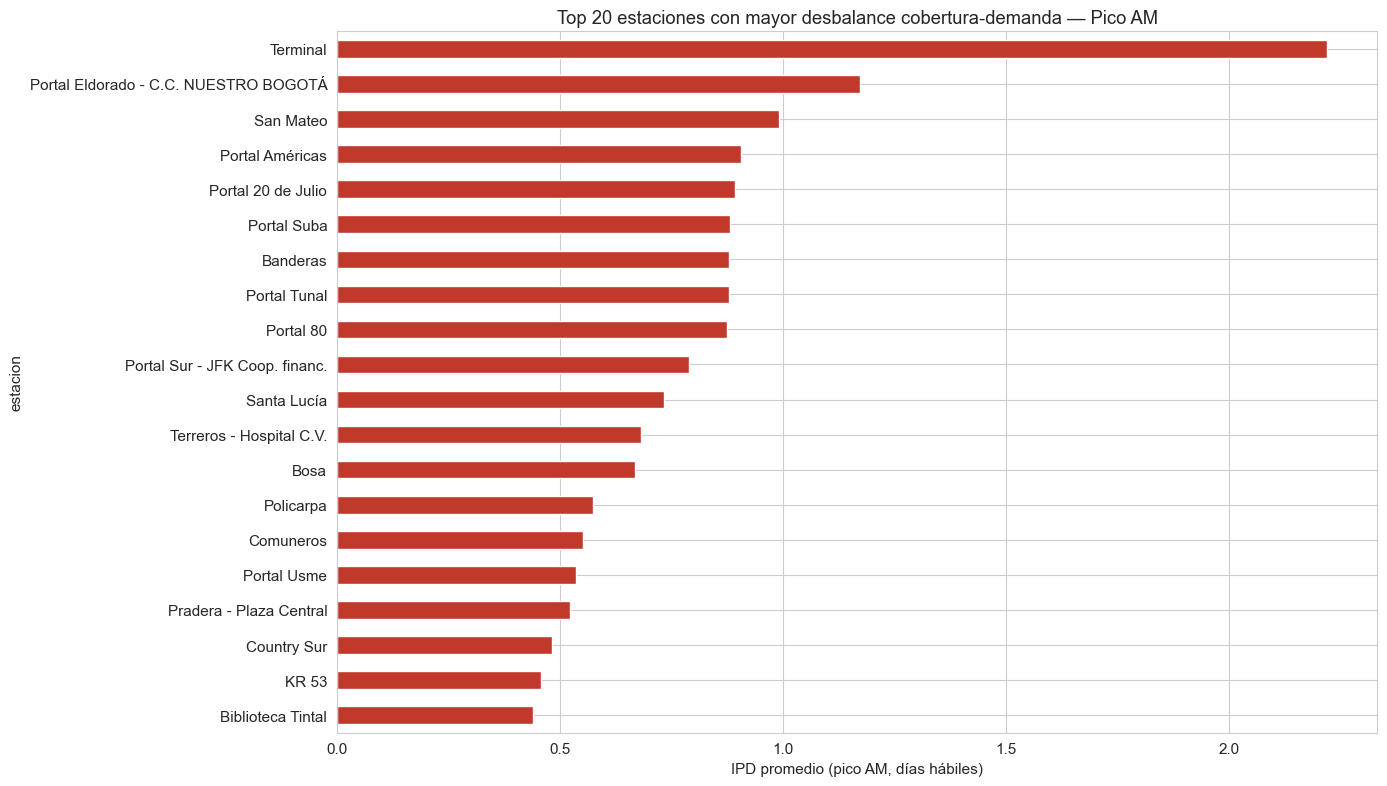

In [11]:
# =============================================
# TOP 20 ESTACIONES CON MAYOR DESBALANCE (PICO AM, DÍAS HÁBILES)
# =============================================

habiles_pico = ipd_df[
    (ipd_df['dia_semana'] < 5) &
    (ipd_df['es_festivo'] == 0) &
    (ipd_df['hora'].between(6, 8))
]

ipd_pico = habiles_pico.groupby('estacion')['ipd'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
ipd_pico.head(20).plot(kind='barh', ax=ax, color='#c0392b')
ax.set_xlabel('IPD promedio (pico AM, días hábiles)')
ax.set_title('Top 20 estaciones con mayor desbalance cobertura-demanda — Pico AM')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig1_ipd_top20_pico_am.png', dpi=150, bbox_inches='tight')
plt.show()

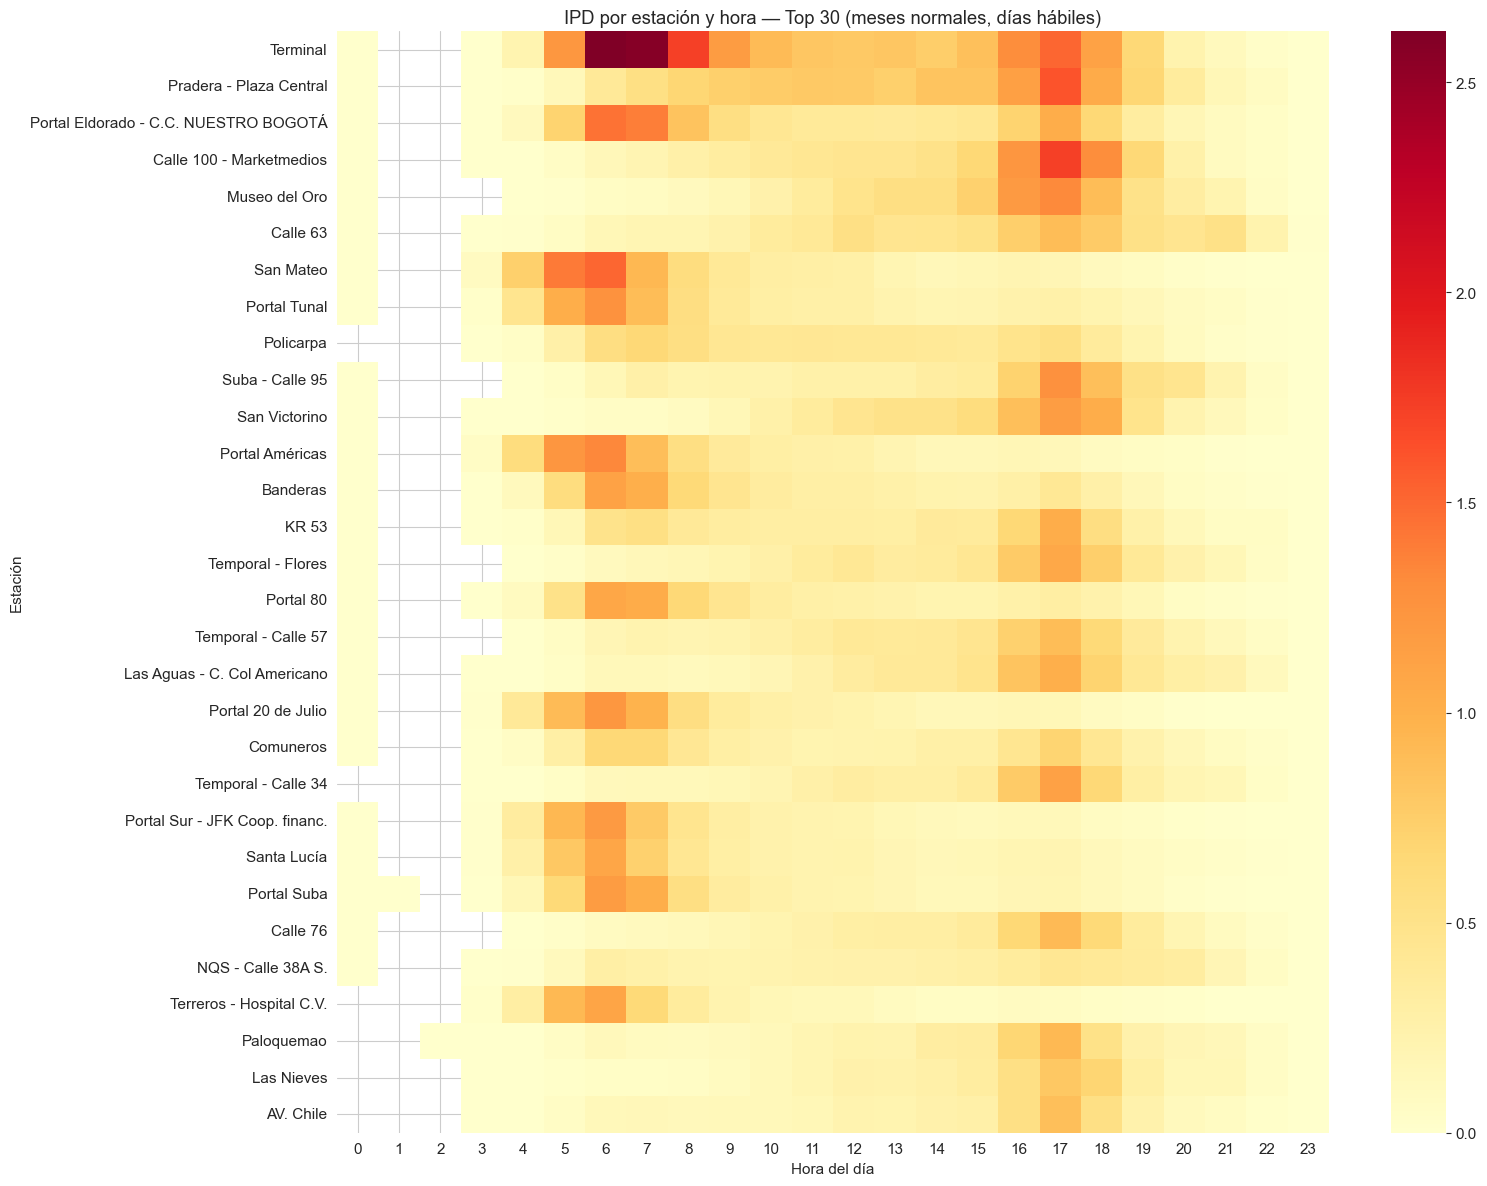

In [12]:
# =============================================
# HEATMAP: IPD POR ESTACIÓN Y HORA (MESES NORMALES, HÁBILES)
# =============================================

meses_normales = [2, 3, 4, 5, 8, 9, 10, 11]
habil_normal = ipd_df[
    (ipd_df['mes'].isin(meses_normales)) &
    (ipd_df['dia_semana'] < 5) &
    (ipd_df['es_festivo'] == 0)
]

heatmap_data = habil_normal.groupby(['estacion', 'hora'])['ipd'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='estacion', columns='hora', values='ipd')
heatmap_pivot['mean_ipd'] = heatmap_pivot.mean(axis=1)
heatmap_pivot = heatmap_pivot.sort_values('mean_ipd', ascending=False).drop('mean_ipd', axis=1)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(heatmap_pivot.head(30), cmap='YlOrRd', annot=False,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('IPD por estación y hora — Top 30 (meses normales, días hábiles)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Estación')
plt.tight_layout()
plt.savefig('fig2_heatmap_ipd.png', dpi=150, bbox_inches='tight')
plt.show()

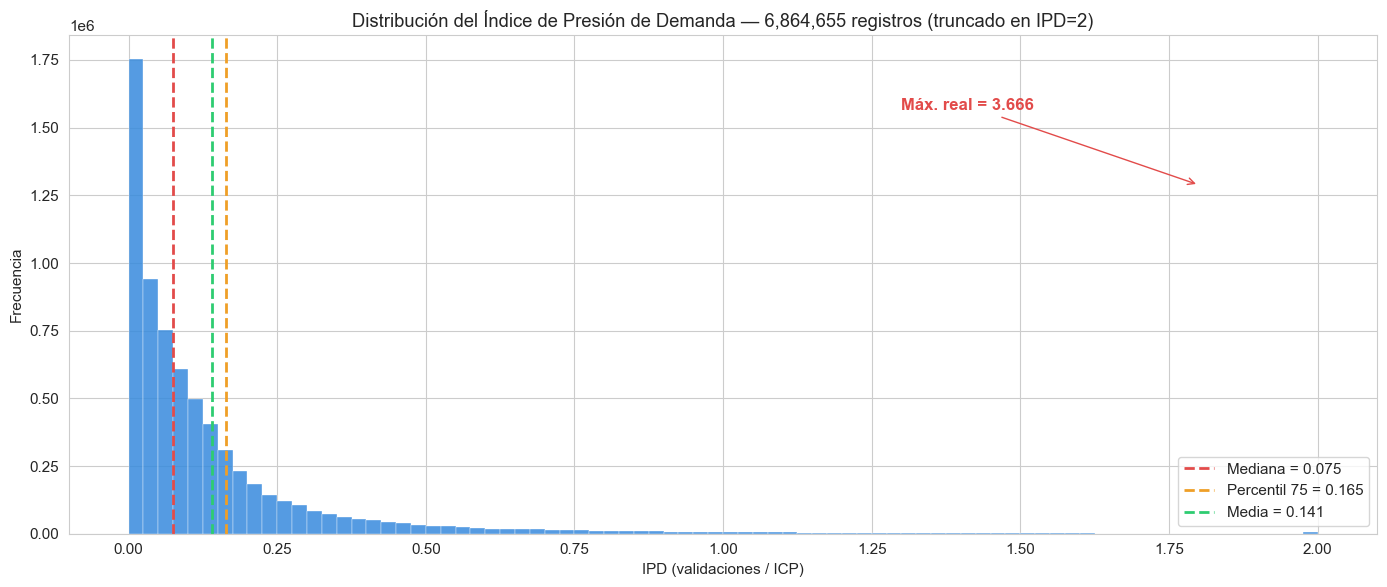

In [25]:
# =============================================
# DISTRIBUCIÓN DEL IPD (HISTOGRAMA)
# =============================================

fig, ax = plt.subplots(figsize=(14, 6))

# Histograma con corte en IPD=2 para ver bien la distribución
ipd_plot = ipd_df['ipd'].clip(upper=2.0)
ax.hist(ipd_plot, bins=80, color='#378ADD', edgecolor='white', linewidth=0.3, alpha=0.85)

# Líneas de referencia
ax.axvline(ipd_df['ipd'].median(), color='#E24B4A', linestyle='--', linewidth=2,
           label=f'Mediana = {ipd_df["ipd"].median():.3f}')
ax.axvline(ipd_df['ipd'].quantile(0.75), color='#EF9F27', linestyle='--', linewidth=2,
           label=f'Percentil 75 = {ipd_df["ipd"].quantile(0.75):.3f}')
ax.axvline(ipd_df['ipd'].mean(), color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Media = {ipd_df["ipd"].mean():.3f}')

ax.set_xlabel('IPD (validaciones / ICP)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución del Índice de Presión de Demanda — {len(ipd_df):,} registros (truncado en IPD=2)')
ax.legend(fontsize=11)
ax.annotate(f'Máx. real = {ipd_df["ipd"].max():.3f}', xy=(1.8, ax.get_ylim()[1]*0.7),
            fontsize=12, color='#E24B4A', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E24B4A'),
            xytext=(1.3, ax.get_ylim()[1]*0.85))
plt.tight_layout()
plt.savefig('fig0_distribucion_ipd.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Clasificación de estaciones (análisis de conglomerados)

Se agrupan las estaciones según su perfil temporal de presión de demanda usando K-Means con estandarización z-score.

In [13]:
# =============================================
# PERFILES PARA CLUSTERING
# =============================================

perfiles = habil_normal.groupby(['estacion', 'hora'])['ipd'].mean().reset_index()
perfiles_pivot = perfiles.pivot(index='estacion', columns='hora', values='ipd').fillna(0)

perfiles_pivot['ipd_mean'] = perfiles_pivot.mean(axis=1)
perfiles_pivot['ipd_std'] = perfiles_pivot.iloc[:, :-1].std(axis=1)
perfiles_pivot['ipd_max'] = perfiles_pivot.iloc[:, :-2].max(axis=1)

# Convertir columnas a string
perfiles_pivot.columns = perfiles_pivot.columns.astype(str)
features_cols = perfiles_pivot.columns.tolist()

# Estandarización z-score
scaler = StandardScaler()
X_cluster = scaler.fit_transform(perfiles_pivot[features_cols])

print(f"Features para clustering: {X_cluster.shape[1]} variables, {X_cluster.shape[0]} estaciones")

Features para clustering: 27 variables, 123 estaciones


K=2: inercia=2231, silhouette=0.481
K=3: inercia=1696, silhouette=0.508
K=4: inercia=1318, silhouette=0.515
K=5: inercia=942, silhouette=0.523
K=6: inercia=766, silhouette=0.392
K=7: inercia=673, silhouette=0.420
K=8: inercia=596, silhouette=0.368


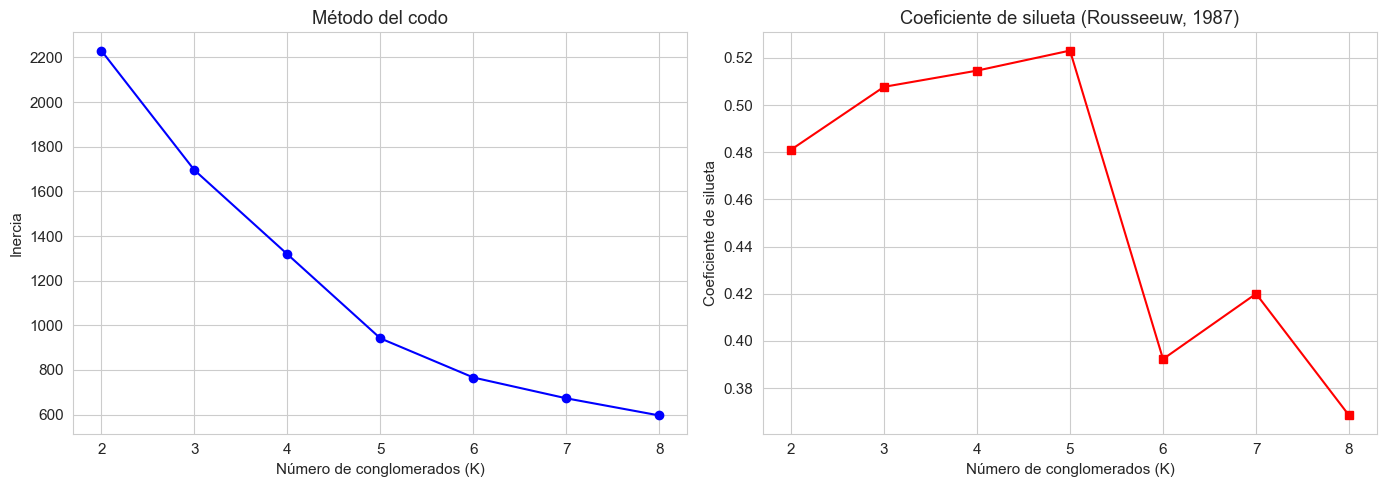


K óptimo por silueta: 5


In [14]:
# =============================================
# SELECCIÓN DE K (MÉTODO DEL CODO + COEFICIENTE DE SILUETA)
# =============================================

inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: inercia={km.inertia_:.0f}, silhouette={sil:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de conglomerados (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del codo')

ax2.plot(K_range, silhouette_scores, 'rs-')
ax2.set_xlabel('Número de conglomerados (K)')
ax2.set_ylabel('Coeficiente de silueta')
ax2.set_title('Coeficiente de silueta (Rousseeuw, 1987)')

plt.tight_layout()
plt.savefig('fig3_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nK óptimo por silueta: {list(K_range)[silhouette_scores.index(max(silhouette_scores))]}")

In [15]:
# =============================================
# K-MEANS — K=4
# =============================================

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
perfiles_pivot['cluster'] = km.fit_predict(X_cluster)

print("Resumen por conglomerado:\n")
for c in range(K):
    est_cluster = perfiles_pivot[perfiles_pivot['cluster'] == c]
    print(f"Conglomerado {c}: {len(est_cluster)} estaciones")
    print(f"  IPD promedio: {est_cluster['ipd_mean'].mean():.3f}")
    print(f"  IPD máximo:   {est_cluster['ipd_max'].mean():.3f}")
    print(f"  Estaciones:   {', '.join(est_cluster.index[:5])}")
    if len(est_cluster) > 5:
        print(f"                ... y {len(est_cluster)-5} más")
    print()

cluster_df = perfiles_pivot[['cluster', 'ipd_mean', 'ipd_max']].reset_index()

Resumen por conglomerado:

Conglomerado 0: 83 estaciones
  IPD promedio: 0.088
  IPD máximo:   0.358
  Estaciones:   21 Ángeles, 7 de agosto, AV. 68, AV. Rojas - UNISALESIANA, AV. Suba - Calle 116
                ... y 78 más

Conglomerado 1: 13 estaciones
  IPD promedio: 0.260
  IPD máximo:   1.183
  Estaciones:   Banderas, Bosa, Portal 20 de Julio, Portal 80, Portal Américas
                ... y 8 más

Conglomerado 2: 2 estaciones
  IPD promedio: 0.662
  IPD máximo:   2.115
  Estaciones:   Pradera - Plaza Central, Terminal

Conglomerado 3: 25 estaciones
  IPD promedio: 0.230
  IPD máximo:   0.898
  Estaciones:   AV. Chile, AV. Jiménez, Calle 100 - Marketmedios, Calle 187, Calle 63
                ... y 20 más



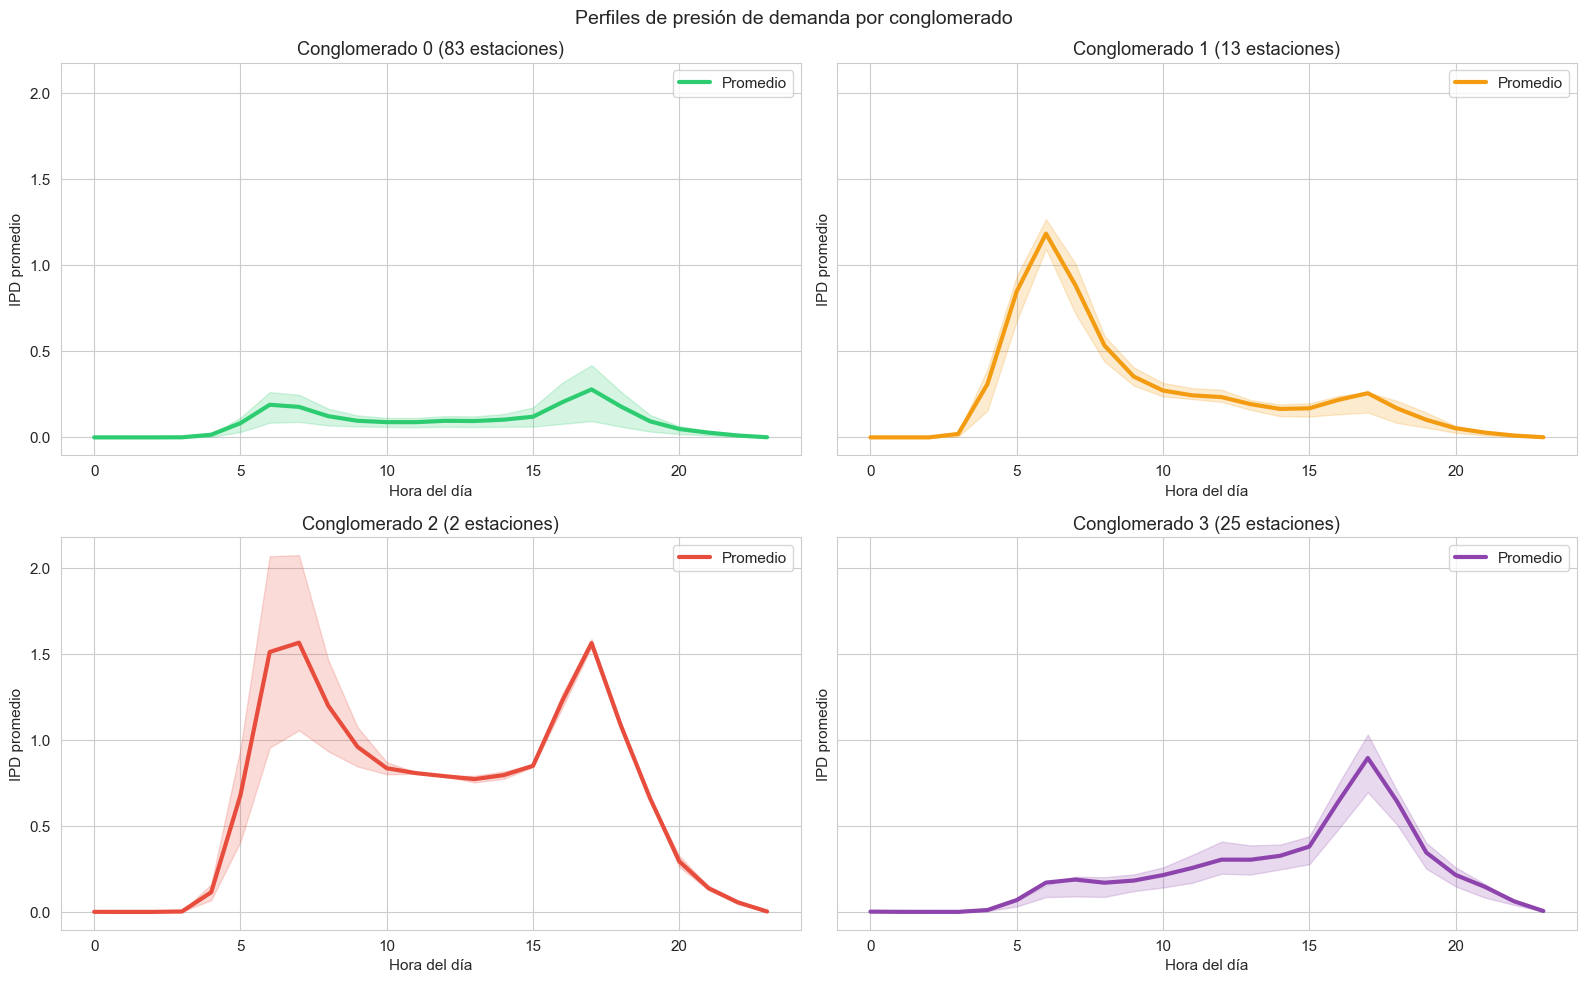

In [16]:
# =============================================
# PERFILES POR CONGLOMERADO
# =============================================

hora_cols = [c for c in perfiles_pivot.columns
             if c not in ['cluster', 'ipd_mean', 'ipd_std', 'ipd_max']
             and c.isdigit()]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for c in range(K):
    ax = axes[c // 2][c % 2]
    cluster_data = perfiles_pivot[perfiles_pivot['cluster'] == c][hora_cols]
    mean_profile = cluster_data.mean()
    x = [int(h) for h in mean_profile.index]
    ax.plot(x, mean_profile.values, color=colors[c], linewidth=3, label='Promedio')
    ax.fill_between(x,
                    cluster_data.quantile(0.25).values,
                    cluster_data.quantile(0.75).values,
                    alpha=0.2, color=colors[c])
    ax.set_title(f'Conglomerado {c} ({len(cluster_data)} estaciones)')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('IPD promedio')
    ax.legend()

plt.suptitle('Perfiles de presión de demanda por conglomerado', fontsize=14)
plt.tight_layout()
plt.savefig('fig4_perfiles_conglomerados.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluación de la capacidad explicativa de los indicadores

El propósito de este modelo **no es predecir demanda futura**, sino evaluar si los indicadores ICP y conglomerado aportan información estructural por encima de las variables puramente temporales.

In [17]:
# =============================================
# PREPARACIÓN DE FEATURES
# =============================================

cluster_map = cluster_df.set_index('estacion')['cluster'].to_dict()
ipd_df['cluster'] = ipd_df['estacion'].map(cluster_map)

station_codes = {s: i for i, s in enumerate(sorted(ipd_df['estacion'].unique()))}
ipd_df['estacion_code'] = ipd_df['estacion'].map(station_codes)

feature_cols = ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo',
                'icp', 'n_rutas', 'cluster', 'estacion_code']

base_features = ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'estacion_code']

model_df = ipd_df.dropna(subset=feature_cols + ['validaciones']).copy()
model_df['cluster'] = model_df['cluster'].astype(int)

print(f"Datos para modelo: {len(model_df):,} filas")
print(f"Features modelo base:     {base_features}")
print(f"Features modelo completo: {feature_cols}")

X = model_df[feature_cols]
y = model_df['validaciones']

Datos para modelo: 6,864,655 filas
Features modelo base:     ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'estacion_code']
Features modelo completo: ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'icp', 'n_rutas', 'cluster', 'estacion_code']


In [18]:
# =============================================
# PARTICIÓN TEMPORAL (80/20)
# =============================================

split_date = model_df['fecha'].quantile(0.8)
train_mask = model_df['fecha'] <= split_date

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train):,} filas (hasta {split_date.strftime('%Y-%m-%d')})")
print(f"Test:  {len(X_test):,} filas (después)")

Train: 5,493,897 filas (hasta 2025-08-02)
Test:  1,370,758 filas (después)


In [19]:
# =============================================
# MODELO BASE (SIN ICP NI CONGLOMERADO)
# =============================================

xgb_params = dict(n_estimators=300, max_depth=8, learning_rate=0.1,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

xgb_base = XGBRegressor(**xgb_params)
xgb_base.fit(X_train[base_features], y_train)
y_pred_base = xgb_base.predict(X_test[base_features])

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)

print(f"MODELO BASE (solo variables temporales + estación)")
print(f"  RMSE: {rmse_base:.2f}")
print(f"  MAE:  {mae_base:.2f}")
print(f"  R²:   {r2_base:.4f}")

MODELO BASE (solo variables temporales + estación)
  RMSE: 85.85
  MAE:  40.25
  R²:   0.9160


In [20]:
# =============================================
# MODELO COMPLETO (CON ICP Y CONGLOMERADO)
# =============================================

xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X_train, y_train)
y_pred_full = xgb_full.predict(X_test)

rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))
r2_full = r2_score(y_test, y_pred_full)
mae_full = mean_absolute_error(y_test, y_pred_full)

print(f"MODELO COMPLETO (con ICP + conglomerado)")
print(f"  RMSE: {rmse_full:.2f}")
print(f"  MAE:  {mae_full:.2f}")
print(f"  R²:   {r2_full:.4f}")

print(f"\n{'='*50}")
print(f"CONTRIBUCIÓN DE LOS INDICADORES:")
print(f"  RMSE: {rmse_base:.2f} -> {rmse_full:.2f} ({(rmse_base-rmse_full)/rmse_base*100:.1f}% mejora)")
print(f"  R²:   {r2_base:.4f} -> {r2_full:.4f} (+{r2_full-r2_base:.4f})")

MODELO COMPLETO (con ICP + conglomerado)
  RMSE: 77.98
  MAE:  32.76
  R²:   0.9307

CONTRIBUCIÓN DE LOS INDICADORES:
  RMSE: 85.85 -> 77.98 (9.2% mejora)
  R²:   0.9160 -> 0.9307 (+0.0147)


In [21]:
# =============================================
# COMPARACIÓN: XGBoost vs Random Forest
# =============================================

rf = RandomForestRegressor(
    n_estimators=300, max_depth=8,
    max_features=0.8, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Intentar LightGBM si está disponible
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
    r2_lgb = r2_score(y_test, y_pred_lgb)
    mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
    has_lgb = True
except ImportError:
    has_lgb = False

print("=" * 60)
print("COMPARACIÓN DE ALGORITMOS (modelo completo)")
print("=" * 60)
print(f"{'Algoritmo':<20} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 50)
print(f"{'XGBoost':<20} {rmse_full:>10.2f} {mae_full:>10.2f} {r2_full:>10.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>10.2f} {mae_rf:>10.2f} {r2_rf:>10.4f}")
if has_lgb:
    print(f"{'LightGBM':<20} {rmse_lgb:>10.2f} {mae_lgb:>10.2f} {r2_lgb:>10.4f}")

COMPARACIÓN DE ALGORITMOS (modelo completo)
Algoritmo                  RMSE        MAE         R²
--------------------------------------------------
XGBoost                   77.98      32.76     0.9307
Random Forest            127.17      61.44     0.8156
LightGBM                  84.89      40.19     0.9178


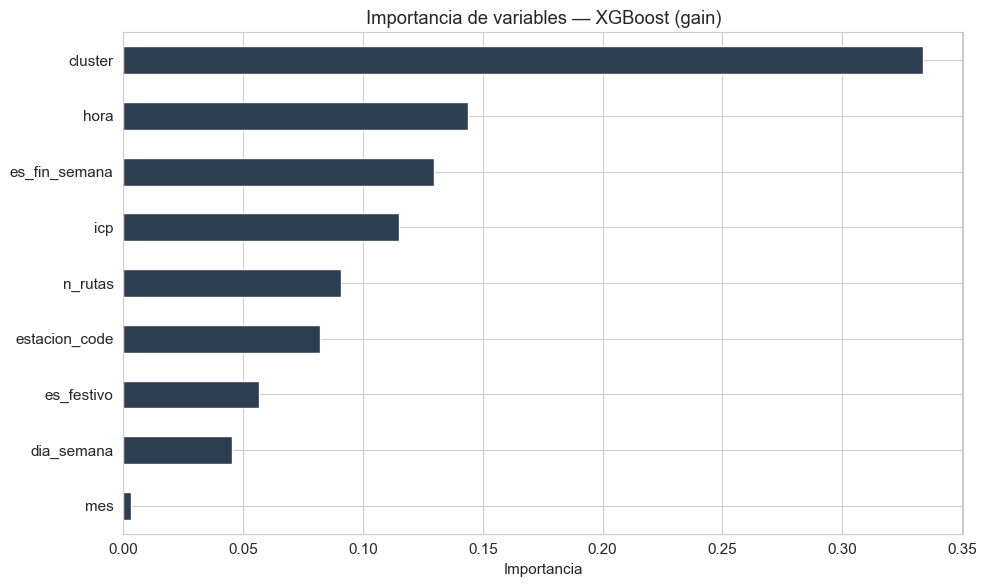

In [22]:
# =============================================
# IMPORTANCIA DE VARIABLES
# =============================================

importance = pd.Series(xgb_full.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax, color='#2c3e50')
ax.set_title('Importancia de variables — XGBoost (gain)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('fig5_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

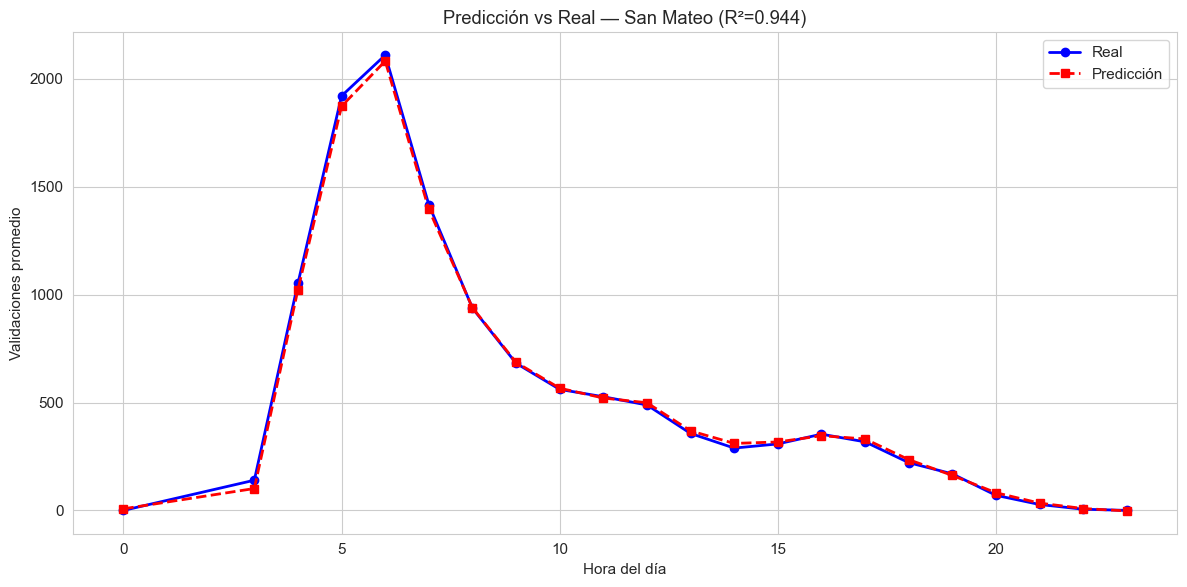

In [23]:
# =============================================
# PREDICCIÓN VS REAL — ESTACIÓN EJEMPLO
# =============================================

test_df = model_df[~train_mask].copy()
test_df['y_pred'] = y_pred_full

station_r2 = {}
for est in test_df['estacion'].unique():
    mask = test_df['estacion'] == est
    if mask.sum() > 100:
        station_r2[est] = r2_score(test_df.loc[mask, 'validaciones'], test_df.loc[mask, 'y_pred'])

best_station = max(station_r2, key=station_r2.get)

est_data = test_df[test_df['estacion'] == best_station]
real_profile = est_data.groupby('hora')['validaciones'].mean()
pred_profile = est_data.groupby('hora')['y_pred'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(real_profile.index, real_profile.values, 'b-o', label='Real', linewidth=2)
ax.plot(pred_profile.index, pred_profile.values, 'r--s', label='Predicción', linewidth=2)
ax.set_title(f'Predicción vs Real — {best_station} (R²={station_r2[best_station]:.3f})')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Validaciones promedio')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_prediccion_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Exportación de resultados

In [24]:
# =============================================
# GUARDAR RESULTADOS
# =============================================

icp.to_csv('icp_estaciones.csv', index=False)
print(f"Guardado: icp_estaciones.csv ({len(icp)} estaciones)")

ipd_export = ipd_df[['estacion', 'fecha', 'intervalo', 'hora', 'dia_semana', 'mes',
                      'validaciones', 'icp', 'n_rutas', 'ipd', 'cluster']].copy()
ipd_export.to_csv('ipd_completo.csv', index=False)
print(f"Guardado: ipd_completo.csv ({len(ipd_export):,} filas)")

cluster_df.to_csv('conglomerados_estaciones.csv', index=False)
print(f"Guardado: conglomerados_estaciones.csv ({len(cluster_df)} estaciones)")

metricas = pd.DataFrame({
    'Modelo': ['Base (sin ICP/conglomerado)', 'Completo (con ICP/conglomerado)', 'Random Forest (completo)'],
    'RMSE': [rmse_base, rmse_full, rmse_rf],
    'MAE': [mae_base, mae_full, mae_rf],
    'R2': [r2_base, r2_full, r2_rf]
})
metricas.to_csv('metricas_modelo.csv', index=False)
print(f"Guardado: metricas_modelo.csv")
print(f"\nTodos los resultados exportados.")

Guardado: icp_estaciones.csv (216 estaciones)
Guardado: ipd_completo.csv (6,864,655 filas)
Guardado: conglomerados_estaciones.csv (123 estaciones)
Guardado: metricas_modelo.csv

Todos los resultados exportados.
